# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [3]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

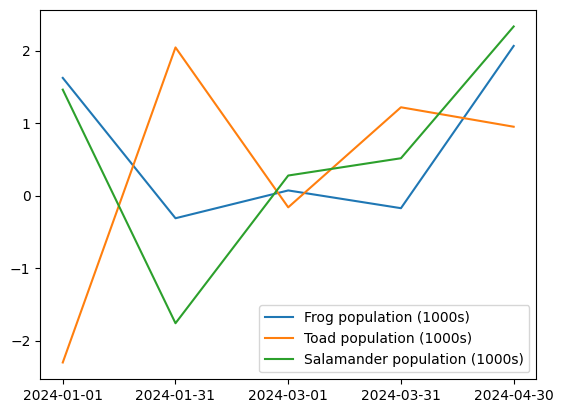

In [7]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

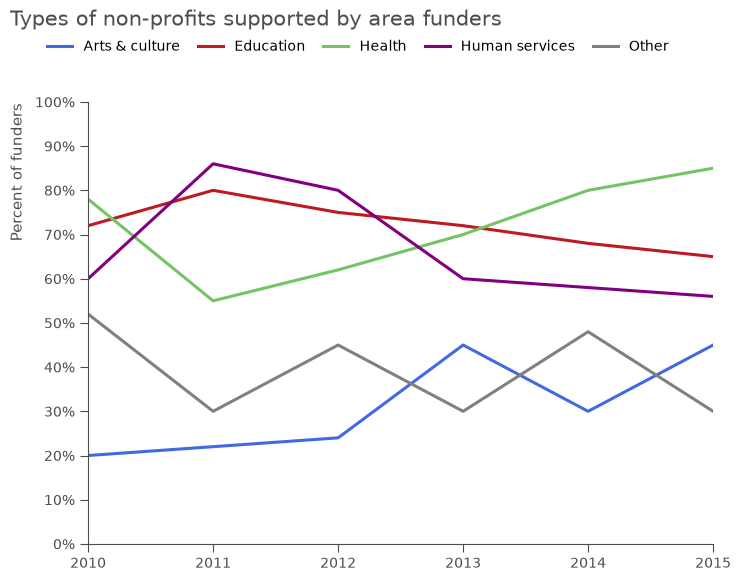

In [8]:
# Spaghetti Graph (Figure 9.21 on pg. 228)

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
years = [2010, 2011, 2012, 2013, 2014, 2015]

series = [
    ('Arts & culture', [20, 22, 24, 45, 30, 45], '#4169E1'),
    ('Education', [72, 80, 75, 72, 68, 65], '#BC1B22'),
    ('Health', [78, 55, 62, 70, 80, 85], '#74C365'),
    ('Human services', [60, 86, 80, 60, 58, 56], 'purple'),
    ('Other', [52, 30, 45, 30, 48, 30], 'grey'),
]

dark_grey = '#4d4d4d'

# ------------------------------------------------------------------
# Figure + axes
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.subplots_adjust(top=0.78, bottom=0.1, left=0.11, right=0.735)

for name, values, color in series:
    ax.plot(years, values, color=color, linewidth=2.2, label=name)

# --- X-axis: 2010-2015, starting right at the y-axis ---
ax.set_xlim(2010, 2015)
ax.set_xticks(years)
ax.tick_params(axis='x', length=6, colors=dark_grey)

# --- Y-axis: 0%-100% in 10% increments ---
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f'{v}%' for v in range(0, 101, 10)])
ax.tick_params(axis='y', length=6, colors=dark_grey)

# --- Spines: only left & bottom, dark grey ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(dark_grey)
ax.spines['bottom'].set_color(dark_grey)

# --- Y-axis label, to the left of the y-axis values, rotated 90 degrees,
#     ending level with the 100% tick ---
ax.set_ylabel('Percent of funders', color=dark_grey, fontsize=11)
ax.yaxis.label.set_verticalalignment('top')
ax.yaxis.set_label_coords(-0.125, 0.841)  # x: pushed further left for spacing from the tick values

# --- Compute alignment reference points: left edge of the y-axis VALUES
#     (tick labels) and left edge of the y-axis LABEL ---
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

yvalues_xmin = min(t.get_window_extent(renderer).x0 for t in ax.get_yticklabels())
yvalues_axes_x = ax.transAxes.inverted().transform((yvalues_xmin, 0))[0]

ylabel_xmin = ax.yaxis.label.get_window_extent(renderer).x0
ylabel_axes_x = ax.transAxes.inverted().transform((ylabel_xmin, 0))[0]

# --- Legend: single row, starting where the y-axis values start, black text ---
legend = ax.legend(loc='lower left', bbox_to_anchor=(yvalues_axes_x, 1.08), ncol=5,
                    frameon=False, handlelength=1.8, columnspacing=1.3, fontsize=10)
for text in legend.get_texts():
    text.set_color('black')

# --- Title: regular weight, dark grey, aligned with the y-axis label ---
ax.set_title('Types of non-profits supported by area funders', fontsize=15, fontweight='normal',
              loc='left', x=ylabel_axes_x, color=dark_grey, pad=55)

plt.show()